In [1]:
import pandas as pd
import os
import urllib.request

In [2]:
base_url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/"
datasets = ['ETTh1.csv', 'ETTh2.csv']
data_dir = 'ett_data'
os.makedirs(data_dir, exist_ok=True)

for ds in datasets:
    filepath = os.path.join(data_dir, ds)
    if not os.path.exists(filepath):
        print(f"Downloading {ds}...")
        urllib.request.urlretrieve(base_url + ds, filepath)
        print(f"Downloaded {ds}")
    else:
        print(f"{ds} already exists")


Downloaded ETTh1.csv
Downloaded ETTh2.csv


In [3]:
etth1 = pd.read_csv(os.path.join(data_dir, 'ETTh1.csv'))
etth2 = pd.read_csv(os.path.join(data_dir, 'ETTh2.csv'))


In [4]:
etth1['date'] = pd.to_datetime(etth1['date'])
etth2['date'] = pd.to_datetime(etth2['date'])

In [5]:
print(f"ETTh1 dataset shape: {etth1.shape}")
print(f"ETTh2 dataset shape: {etth2.shape}")

ETTh1 dataset shape: (17420, 8)
ETTh2 dataset shape: (17420, 8)


In [6]:
print("\nETTh1 sample data:")
print(etth1.head())


ETTh1 sample data:
                 date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0 2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1 2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2 2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3 2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4 2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000


In [7]:
print("\nETTh2 sample data:")
print(etth2.head())


ETTh2 sample data:
                 date       HUFL    HULL       MUFL   MULL   LUFL   LULL  \
0 2016-07-01 00:00:00  41.130001  12.481  36.535999  9.355  4.424  1.311   
1 2016-07-01 01:00:00  37.528000  10.136  33.936001  7.532  4.435  1.215   
2 2016-07-01 02:00:00  37.946999  11.309  35.330002  9.007  2.100  0.000   
3 2016-07-01 03:00:00  38.952000  11.895  35.543999  9.436  3.380  1.215   
4 2016-07-01 04:00:00  38.113998  11.476  35.410000  9.623  2.036  0.000   

          OT  
0  38.661999  
1  37.124001  
2  36.465000  
3  33.608501  
4  31.850500  


In [8]:
df1 = etth1.drop(['HUFL','MUFL','LULL','LUFL'],axis=1)

In [9]:
df2 = etth2.drop(['HUFL','MUFL','LULL','LUFL'],axis=1)

In [10]:
df1.rename(columns={'date':'datetime','HULL':'feature1','MULL':'feature2','OT':'target'},inplace=True)
df2.rename(columns={'date':'datetime','HULL':'feature1','MULL':'feature2','OT':'target'},inplace=True)

In [11]:
df1 = df1.set_index('datetime')
df2 = df2.set_index('datetime')

In [12]:
!pip install -q "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 705.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.9 MB/s

In [13]:
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

In [14]:
ttm_model1 = TinyTimeMixerForPrediction.from_pretrained("ibm/TTM", revision="main")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.24M [00:00<?, ?B/s]

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [16]:
# ================== FREEZE BACKBONE ==================
def freeze_ttm_backbone(model):
    backbone_tokens = ['patch', 'tsmixer_block', 'tsmixer', 'mixer', 'backbone',
                       'prefix', 'patch_embedding', 'merge']
    frozen = 0
    total = 0
    for name, param in model.named_parameters():
        total += 1
        if any(tok in name.lower() for tok in backbone_tokens):
            param.requires_grad = False
            frozen += 1
        else:
            param.requires_grad = True

    print(f"Frozen {frozen}/{total} parameters (backbone).")
    trainable_count = sum(p.numel()
                          for p in model.parameters()
                          if p.requires_grad
    )
    total_count = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable_count}/{total_count} ({100*trainable_count/total_count:.2f}%)\n")


In [31]:
# ================== AUTOREGRESSIVE TRAINING + VALIDATION ==================
def autoregressive_train(model, train_data, val_data, num_epochs=15, lr=1e-5, device='cuda'):
    model = model.to(device)
    freeze_ttm_backbone(model)

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable, lr=lr, weight_decay=1e-6)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        # ---------- TRAIN ----------
        model.train()
        total_loss = 0.0
        num_steps = 0
        window = train_data[:context_length].copy()

        for step in range(context_length, len(train_data) - 1):
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            true_target = train_data[step, 2]
            y_true = torch.tensor(true_target, dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(x)
            pred = outputs.prediction_outputs[0, 0, -1]

            loss = criterion(pred, y_true)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_steps += 1

            # Update window autoregressively
            new_row = np.array([train_data[step, 0], train_data[step, 1], pred.item()])
            window = np.vstack([window[1:], new_row.reshape(1, -1)])

        avg_train_loss = total_loss / num_steps
        train_losses.append(avg_train_loss)

        #-------VALIDATION-----

        model.eval()
        with torch.no_grad():
          val_window = val_data[:context_length].copy()
          val_loss = 0.0
          val_steps = 0

          for step in range(context_length, len(val_data) - 1):
            x_val = torch.tensor(val_window, dtype=torch.float32).unsqueeze(0).to(device)
            y_val = torch.tensor(val_data[step, 2], dtype=torch.float32).to(device)

            outputs = model(x_val)
            pred_val = outputs.prediction_outputs[0, 0, -1]

            loss_val = criterion(pred_val, y_val)
            val_loss += loss_val.item()
            val_steps += 1

            new_val_row = np.array([val_data[step, 0], val_data[step, 1], pred_val.item()])
            val_window = np.vstack([val_window[1:], new_val_row.reshape(1, -1)])

            avg_val_loss = val_loss / val_steps
            val_losses.append(avg_val_loss)

            print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

            print("Training completed!\n")


            #------PLOTTING----

            plt.figure(figsize=(8,5))
            plt.plot(train_losses, label = 'Train Loss')
            plt.plot(val_losses, label = 'Validation Loss')
            plt.title('Training vs Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('MSE Loss')
            plt.legend()
            plt.grid(True)
            plt.show()
            return train_losses, val_losses


In [32]:
# ================== AUTOREGRESSIVE EVALUATION ==================
def autoregressive_evaluate(model, data, device='cuda', dataset_name="Eval"):
    model.eval()
    predictions = []
    actuals = []

    window = data[:context_length].copy()

    with torch.no_grad():
        for step in range(context_length, len(data) - 1):
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            true_target = data[step, 2]

            outputs = model(x)
            pred = outputs.prediction_outputs[0, 0, -1].item()

            predictions.append(pred)
            actuals.append(true_target)

            new_row = np.array([data[step, 0], data[step, 1], pred])
            window = np.vstack([window[1:], new_row.reshape(1, -1)])

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mse = np.mean((predictions - actuals) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))

    print(f"{dataset_name} Autoregressive Results:")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}\n")

    # ---------- PLOT PREDICTIONS ----------
    plt.figure(figsize=(10,5))
    plt.plot(actuals, label='Actual', alpha=0.7)
    plt.plot(predictions, label='Predicted', alpha=0.7)
    plt.title(f"{dataset_name} Predictions vs Actuals")
    plt.xlabel("Time Step")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    return predictions, actuals, rmse, mae

TRAINING ON SOURCE DOMAIN (AUTOREGRESSIVE)
Frozen 130/134 parameters (backbone).
Trainable: 123104/805280 (15.29%)

Epoch [1/25] | Train Loss: 12.232850 | Val Loss: 3.501670
Training completed!



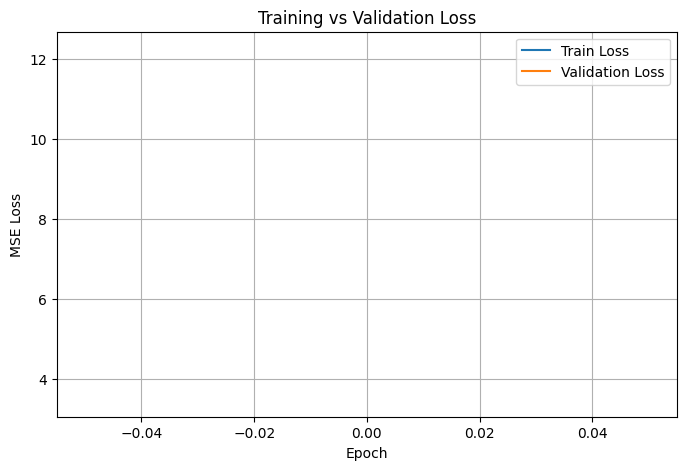

EVALUATION AFTER FINE-TUNING
--- Source Eval (20% split) ---
Source Eval Autoregressive Results:
  RMSE: 3.058384
  MAE:  2.428562



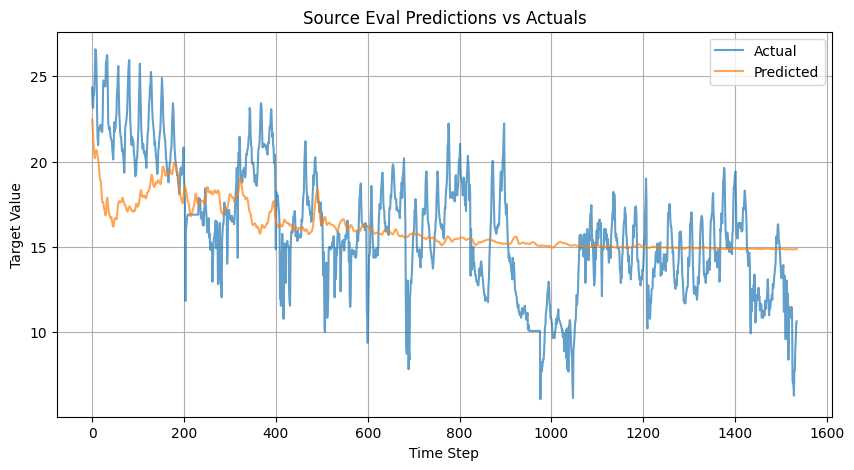

--- Target Domain ---
Target Autoregressive Results:
  RMSE: 6.422379
  MAE:  5.183446



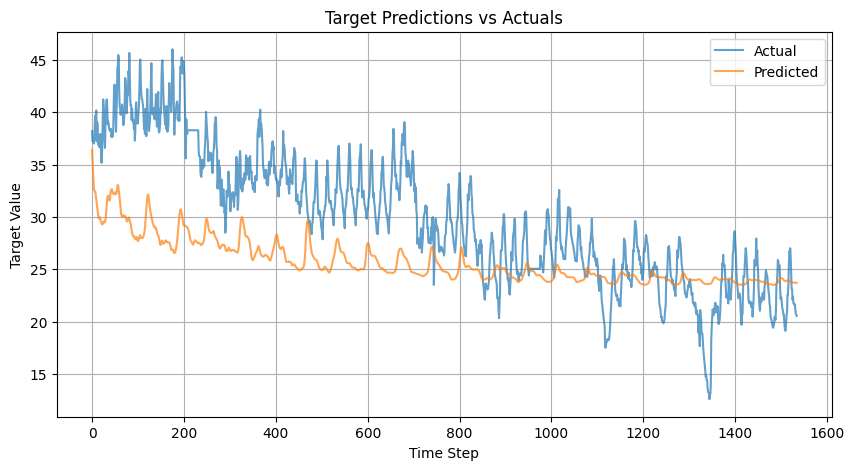

FINAL SUMMARY
Source Eval - RMSE: 3.058384, MAE: 2.428562
Target      - RMSE: 6.422379, MAE: 5.183446


In [34]:
# ================== MAIN EXECUTION ==================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sample_n1 = 2048
sample_n2=2048
df1_small = df1.iloc[:sample_n1]
df2_small = df2.iloc[:sample_n2]
df1_source =df1.iloc[8760:10808]

df1_raw = df1_small[['feature1', 'feature2', 'target']].values
df2_raw = df2_small[['feature1', 'feature2', 'target']].values
df1_source=df1_source[['feature1', 'feature2', 'target']].values

# Example split
split_idx = 1024
source_train = df1_raw
source_eval = df1_source

context_length = 512

print("=" * 60)
print("TRAINING ON SOURCE DOMAIN (AUTOREGRESSIVE)")
print("=" * 60)
train_losses, val_losses = autoregressive_train(
    ttm_model1, source_train, source_eval, num_epochs=25, lr=1e-5, device=device
)

print("=" * 60)
print("EVALUATION AFTER FINE-TUNING")
print("=" * 60)

print("--- Source Eval (20% split) ---")
source_preds, source_actuals, source_rmse, source_mae = autoregressive_evaluate(
    ttm_model1, source_eval, device, dataset_name="Source Eval"
)

print("--- Target Domain ---")
target_preds, target_actuals, target_rmse, target_mae = autoregressive_evaluate(
    ttm_model1, df1_raw, device, dataset_name="Target"
)

print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Source Eval - RMSE: {source_rmse:.6f}, MAE: {source_mae:.6f}")
print(f"Target      - RMSE: {target_rmse:.6f}, MAE: {target_mae:.6f}")

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
ttm_model1.save_pretrained('/content/drive/MyDrive/ttm_finetuned_model/')

In [37]:
loaded_model1 = TinyTimeMixerForPrediction.from_pretrained(
    '/content/drive/MyDrive/ttm_finetuned_model',
    local_files_only=True
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model1 = loaded_model1.to(device)

In [38]:
import math, time
import torch.nn.functional as F
from torch.autograd import Function

In [39]:
torch.manual_seed(42)
np.random.seed(42)

In [40]:
# ----------------- CONFIG -----------------
SEQ_LEN = 512
NUM_EPOCHS = 20
ADV_WEIGHT = 0.1
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [42]:
# ============ DATA PREP ============
sample_n = 2048
sample_n1 = 2048
df1_small = df1.iloc[:sample_n]
df2_small = df2.iloc[:sample_n1]
df1_source=df1.iloc[8760:10808]

vals_src = df1_small[['feature1','feature2']].values
tgt_src = df1_small['target'].values.reshape(-1,1)
data_src = np.hstack([vals_src, tgt_src])
vals_src1 = df1_source[['feature1','feature2']].values
tgt_src1 = df1_source['target'].values.reshape(-1,1)
data_src1 = np.hstack([vals_src1, tgt_src1])


vals_tgt = df2_small[['feature1','feature2']].values
dummy_tgt = np.full((len(vals_tgt),1), np.mean(tgt_src))
data_tgt = np.hstack([vals_tgt, dummy_tgt])
datareal_tgt = df2_small['target'].values.reshape(-1,1)
datareal1_tgt = np.hstack([vals_tgt, datareal_tgt])

# Split source 80/20

data_src_train = data_src
data_src_eval = data_src1

In [43]:
# ============ FREEZE BACKBONE ============
def freeze_ttm_backbone(model):
    backbone_tokens = ['patch', 'tsmixer_block', 'tsmixer', 'mixer', 'backbone', 'prefix', 'patch_embedding', 'merge']
    frozen = 0; total = 0
    for name, param in model.named_parameters():
        total += 1
        if any(tok in name.lower() for tok in backbone_tokens):
            param.requires_grad = False
            frozen += 1
        else:
            param.requires_grad = True
    trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_count = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable_count}/{total_count} ({100*trainable_count/total_count:.2f}%)")

freeze_ttm_backbone(loaded_model1)

Trainable: 123104/805280 (15.29%)


In [61]:
# ============ FEATURE EXTRACTION ============
def get_decoder_features(outputs, model):
    if hasattr(outputs, 'decoder_hidden_state') and outputs.decoder_hidden_state is not None:
        return outputs.decoder_hidden_state.mean(dim=1).mean(dim=1)
    if hasattr(outputs, 'backbone_hidden_state') and outputs.backbone_hidden_state is not None:
        return outputs.backbone_hidden_state.mean(dim=1).mean(dim=1)
    raise RuntimeError("Cannot extract features")


In [64]:
# ============ MODULES ============
class Adapter(nn.Module):
    def __init__(self, in_dim, bottleneck=64):
        super().__init__()
        self.down = nn.Linear(in_dim, bottleneck)
        self.act = nn.ReLU()
        self.up = nn.Linear(bottleneck, in_dim)
        self.ln = nn.LayerNorm(in_dim)
    def forward(self, x): return self.ln(x + self.up(self.act(self.down(x))))

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hid=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.LayerNorm(hid), nn.Linear(hid, out_dim))
    def forward(self, x): return self.net(x)

class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lambda_): ctx.lambda_ = lambda_; return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output): return grad_output.neg() * ctx.lambda_, None

def grl(x, lambda_): return GradientReversalFunction.apply(x, lambda_)

class DomainDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(), nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

# Get feature dim
loaded_model1.eval()
with torch.no_grad():
    window_sample = torch.tensor(data_src_train[:SEQ_LEN], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    outputs_sample = loaded_model1(window_sample)
    decoder_feats_sample = get_decoder_features(outputs_sample, loaded_model1)
    actual_feature_dim = decoder_feats_sample.shape[1]
loaded_model1.train()

# Instantiate
adapter = Adapter(actual_feature_dim, bottleneck=64).to(DEVICE)
proj_head = ProjectionHead(actual_feature_dim, hid=256, out_dim=128).to(DEVICE)
discriminator = DomainDiscriminator(input_dim=128, hidden_dim=256).to(DEVICE)

trainable_params = list(adapter.parameters()) + list(proj_head.parameters())
for n,p in loaded_model1.named_parameters():
    if p.requires_grad: trainable_params.append(p)

optimizer_F = optim.AdamW(trainable_params, lr=1e-5, weight_decay=1e-5)
optimizer_D = optim.AdamW(discriminator.parameters(), lr=1e-5, weight_decay=1e-5)

criterion_forecast = nn.MSELoss()
criterion_domain = nn.BCEWithLogitsLoss()

def lambda_schedule(progress):
    return 2.0 / (1.0 + math.exp(-10.0 * progress)) - 1.0

# ============ AUTOREGRESSIVE TRAINING ============
loaded_model1.train(); adapter.train(); proj_head.train(); discriminator.train()

history = {'task_loss': [], 'domain_loss': [], 'adv_loss': [], 'domain_acc': []}

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    epoch_task_loss = 0.0
    epoch_domain_loss = 0.0
    epoch_adv_loss = 0.0
    epoch_domain_acc = 0.0
    num_steps = 0

    window_src = data_src_train[:SEQ_LEN].copy()
    window_tgt = data_tgt[:SEQ_LEN].copy()

    max_steps = min(len(data_src_train) - SEQ_LEN - 1, len(data_tgt) - SEQ_LEN - 1)

    for step in range(SEQ_LEN, SEQ_LEN + max_steps):
        x_src = torch.tensor(window_src, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        x_tgt = torch.tensor(window_tgt, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        x_all = torch.cat([x_src, x_tgt], dim=0)

        y_src_true = torch.tensor(data_src_train[step, 2], dtype=torch.float32).to(DEVICE)

        outputs = loaded_model1(x_all)
        decoder_feats = adapter(get_decoder_features(outputs, loaded_model1))
        preds_all = outputs.prediction_outputs[:, -1, 2]

        feats_src, feats_tgt = decoder_feats[0:1], decoder_feats[1:2]
        pred_src = preds_all[0]
        pred_tgt = preds_all[1]

        # Train Discriminator
        optimizer_D.zero_grad()
        p_src = F.normalize(proj_head(feats_src).detach(), dim=1)
        p_tgt = F.normalize(proj_head(feats_tgt).detach(), dim=1)
        d_src = discriminator(p_src)
        d_tgt = discriminator(p_tgt)
        label_src = torch.tensor([1.0], device=DEVICE)
        label_tgt = torch.tensor([0.0], device=DEVICE)
        loss_D = 0.5 * (criterion_domain(d_src, label_src) + criterion_domain(d_tgt, label_tgt))
        loss_D.backward()
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=0.5)
        optimizer_D.step()

        with torch.no_grad():
            acc_src = (torch.sigmoid(d_src) > 0.5).float().mean().item()
            acc_tgt = (torch.sigmoid(d_tgt) < 0.5).float().mean().item()
            domain_acc = 0.5 * (acc_src + acc_tgt)

        # Train Feature Extractor
        optimizer_F.zero_grad()
        loss_task = criterion_forecast(pred_src, y_src_true)

        progress = (epoch * max_steps + step - SEQ_LEN) / float(max(1, NUM_EPOCHS * max_steps - 1))
        lambda_val = lambda_schedule(progress)

        proj_all = F.normalize(proj_head(decoder_feats), dim=1)
        proj_rev = grl(proj_all, lambda_val)
        d_logits = discriminator(proj_rev)
        dom_labels = torch.tensor([1.0, 0.0], device=DEVICE)
        loss_adv = criterion_domain(d_logits, dom_labels)
        loss_total = loss_task + ADV_WEIGHT * loss_adv

        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=0.5)
        optimizer_F.step()

        epoch_task_loss += loss_task.item()
        epoch_domain_loss += loss_D.item()
        epoch_adv_loss += loss_adv.item()
        epoch_domain_acc += domain_acc
        num_steps += 1

        new_row_src = np.array([data_src_train[step, 0], data_src_train[step, 1], pred_src.item()])
        new_row_tgt = np.array([data_tgt[step, 0], data_tgt[step, 1], pred_tgt.item()])

        window_src = np.vstack([window_src[1:], new_row_src.reshape(1, -1)])
        window_tgt = np.vstack([window_tgt[1:], new_row_tgt.reshape(1, -1)])

    avg_task = epoch_task_loss / num_steps
    avg_dom = epoch_domain_loss / num_steps
    avg_adv = epoch_adv_loss / num_steps
    avg_dom_acc = epoch_domain_acc / num_steps

    history['task_loss'].append(avg_task)
    history['domain_loss'].append(avg_dom)
    history['adv_loss'].append(avg_adv)
    history['domain_acc'].append(avg_dom_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | TaskLoss: {avg_task:.6f} | DomLoss: {avg_dom:.6f} | AdvLoss: {avg_adv:.6f} | DomAcc: {avg_dom_acc:.4f} | Time: {time.time()-t0:.1f}s")

Epoch 1/20 | TaskLoss: 45.925474 | DomLoss: 0.675976 | AdvLoss: 0.675381 | DomAcc: 0.5909 | Time: 58.8s
Epoch 2/20 | TaskLoss: 134852276242897677030825289318400.000000 | DomLoss: 0.673289 | AdvLoss: 0.675085 | DomAcc: 0.6101 | Time: 56.9s
Epoch 3/20 | TaskLoss: 16.347705 | DomLoss: 0.606427 | AdvLoss: 0.606140 | DomAcc: 0.7231 | Time: 55.2s
Epoch 4/20 | TaskLoss: 7662554621.527899 | DomLoss: 0.601740 | AdvLoss: 0.600731 | DomAcc: 0.6902 | Time: 56.0s
Epoch 5/20 | TaskLoss: 7149.937297 | DomLoss: 0.737423 | AdvLoss: 0.737130 | DomAcc: 0.5713 | Time: 54.9s
Epoch 6/20 | TaskLoss: 12.007555 | DomLoss: 0.745125 | AdvLoss: 0.743203 | DomAcc: 0.4407 | Time: 55.2s
Epoch 7/20 | TaskLoss: 84.144525 | DomLoss: 0.676690 | AdvLoss: 0.670016 | DomAcc: 0.5821 | Time: 61.8s
Epoch 8/20 | TaskLoss: 35.541074 | DomLoss: 0.655462 | AdvLoss: 0.656611 | DomAcc: 0.6153 | Time: 56.2s
Epoch 9/20 | TaskLoss: 18.485309 | DomLoss: 0.671114 | AdvLoss: 0.670760 | DomAcc: 0.5603 | Time: 54.8s
Epoch 10/20 | TaskLoss:


=== EVALUATION ===
Source Eval: RMSE=4.783047, MAE=3.976370
Target: RMSE=37.134570, MAE=34.341359


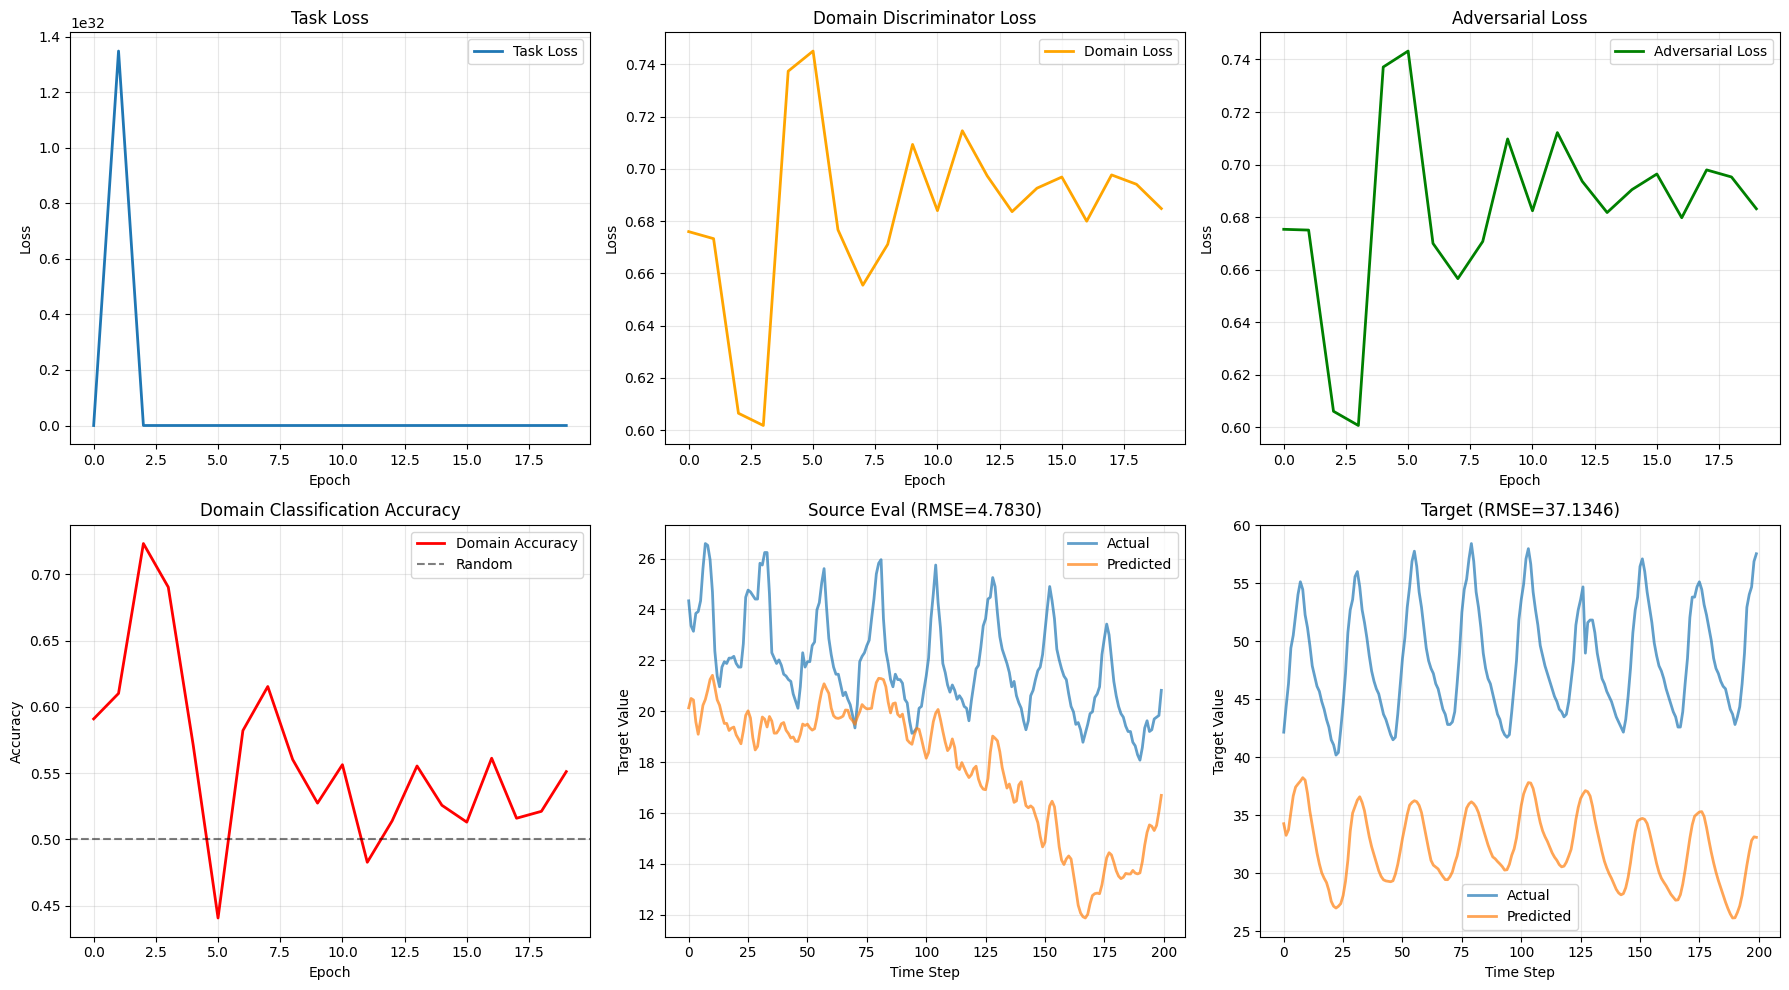

In [70]:
# ============ AUTOREGRESSIVE EVALUATION ============
def autoregressive_evaluate(model, data, device='cuda', dataset_name="Eval"):
    model.eval(); adapter.eval(); proj_head.eval()
    predictions, actuals = [], []
    window = data[:SEQ_LEN].copy()

    with torch.no_grad():
        for step in range(SEQ_LEN, len(data) - 1):
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            outputs = model(x)
            pred = outputs.prediction_outputs[0, -1, 2].item()
            true = data[step, 2]

            predictions.append(pred)
            actuals.append(true)

            new_row = np.array([data[step, 0], data[step, 1], pred])
            window = np.vstack([window[1:], new_row.reshape(1, -1)])

    predictions, actuals = np.array(predictions), np.array(actuals)
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))

    print(f"{dataset_name}: RMSE={rmse:.6f}, MAE={mae:.6f}")
    return predictions, actuals, rmse, mae

print("\n=== EVALUATION ===")
src_preds, src_actuals, src_rmse, src_mae = autoregressive_evaluate(loaded_model1, data_src_eval, DEVICE, "Source Eval")
tgt_preds, tgt_actuals, tgt_rmse, tgt_mae = autoregressive_evaluate(loaded_model1, datareal1_tgt, DEVICE, "Target")

# ============ PLOTS ============
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Training losses
axes[0, 0].plot(history['task_loss'], label='Task Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Task Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(history['domain_loss'], label='Domain Loss', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Domain Discriminator Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[0, 2].plot(history['adv_loss'], label='Adversarial Loss', color='green', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].set_title('Adversarial Loss')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

# Domain accuracy
axes[1, 0].plot(history['domain_acc'], label='Domain Accuracy', color='red', linewidth=2)
axes[1, 0].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Random')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Domain Classification Accuracy')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Source predictions
axes[1, 1].plot(src_actuals[:200], label='Actual', alpha=0.7, linewidth=2)
axes[1, 1].plot(src_preds[:200], label='Predicted', alpha=0.7, linewidth=2)
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Target Value')
axes[1, 1].set_title(f'Source Eval (RMSE={src_rmse:.4f})')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Target predictions
axes[1, 2].plot(tgt_actuals[:200], label='Actual', alpha=0.7, linewidth=2)
axes[1, 2].plot(tgt_preds[:200], label='Predicted', alpha=0.7, linewidth=2)
axes[1, 2].set_xlabel('Time Step')
axes[1, 2].set_ylabel('Target Value')
axes[1, 2].set_title(f'Target (RMSE={tgt_rmse:.4f})')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()




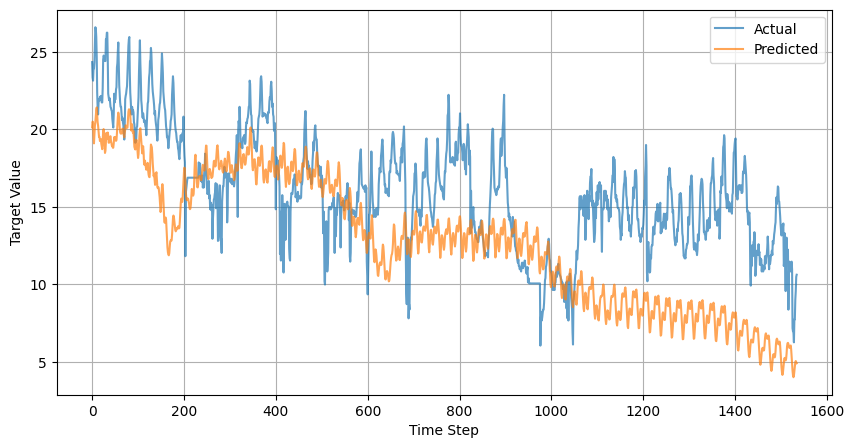

In [73]:
plt.figure(figsize=(10,5))
plt.plot(src_actuals, label='Actual', alpha=0.7)
plt.plot(src_preds, label='Predicted', alpha=0.7)

plt.xlabel("Time Step")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()




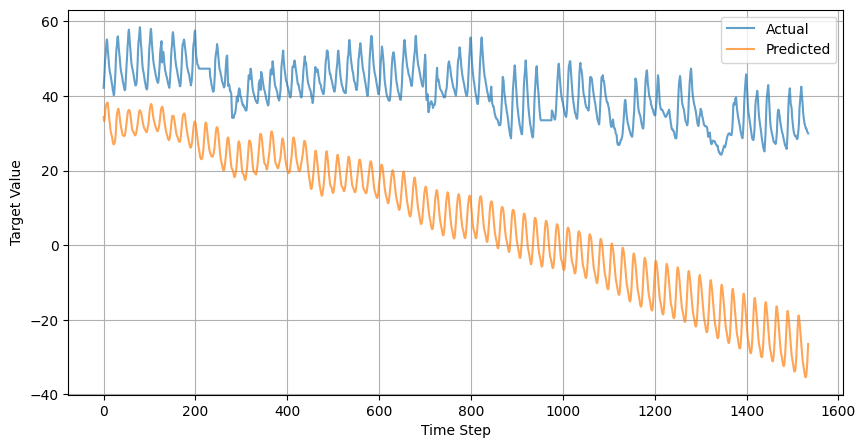

In [74]:
        plt.figure(figsize=(10,5))
        plt.plot(tgt_actuals, label='Actual', alpha=0.7)
        plt.plot(tgt_preds, label='Predicted', alpha=0.7)

        plt.xlabel("Time Step")
        plt.ylabel("Target Value")
        plt.legend()
        plt.grid(True)
        plt.show()

In [75]:
# Source predictions
axes[1, 1].plot(src_actuals[:200], label='Actual', alpha=0.7, linewidth=2)
axes[1, 1].plot(src_preds[:200], label='Predicted', alpha=0.7, linewidth=2)
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Target Value')
axes[1, 1].set_title(f'Source Eval (RMSE={src_rmse:.4f})')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Target predictions
axes[1, 2].plot(tgt_actuals[:200], label='Actual', alpha=0.7, linewidth=2)
axes[1, 2].plot(tgt_preds[:200], label='Predicted', alpha=0.7, linewidth=2)
axes[1, 2].set_xlabel('Time Step')
axes[1, 2].set_ylabel('Target Value')
axes[1, 2].set_title(f'Target (RMSE={tgt_rmse:.4f})')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>